# Griffiths QM
## Chapter 4 — Visualizations

| Section | Problem |
|:--|:--|
| §4.2 & 4.4 | Hydrogen radial wavefunctions and probability densities |
| §4.11 | Spin-½ general spinor — Bloch sphere |
| §4.12 | Larmor precession of spin expectation value |
| §4.13 | Addition of angular momenta — CG coefficients || §4.17 | Minimal coupling and the Aharonov-Bohm fringe shift |


In [1]:
# ── Setup ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.special import genlaguerre, factorial

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.labelsize': 12, 'axes.titlesize': 13,
    'legend.fontsize': 10,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
})

BLUE  = '#2471a3'; RED   = '#c0392b'; GREEN = '#1e8449'
GRAY  = '#7f8c8d'; NAVY  = '#1a3a5c'; PURP  = '#8e44ad'
ORG   = '#d35400'; TEAL  = '#117a65'

figures = []
print('Setup complete.')


Setup complete.


---
## Problem 4.2 & 4.4 — Hydrogen Radial Wavefunctions and Probability Densities {#md_4_2}

Visualize $R_{nl}(r)$ and the radial probability density $P(r) = r^2|R_{nl}(r)|^2$ for the first several hydrogen states.
Mark the most probable radius and $\langle r\rangle$ for each state.

Normalization check (should be 1.000):
  R_10 (1s): 1.000000
  R_20 (2s): 1.000000
  R_21 (2p): 1.000000
  R_30 (3s): 1.000000
  R_31 (3p): 1.000000
  R_32 (3d): 1.000000

1s: r_mp=1.000 a0, <r>=1.500 a0
2s: r_mp=5.231 a0, <r>=6.000 a0
2p: r_mp=4.001 a0, <r>=5.000 a0
3s: r_mp=13.073 a0, <r>=13.500 a0
3p: r_mp=12.003 a0, <r>=12.500 a0
3d: r_mp=9.002 a0, <r>=10.500 a0


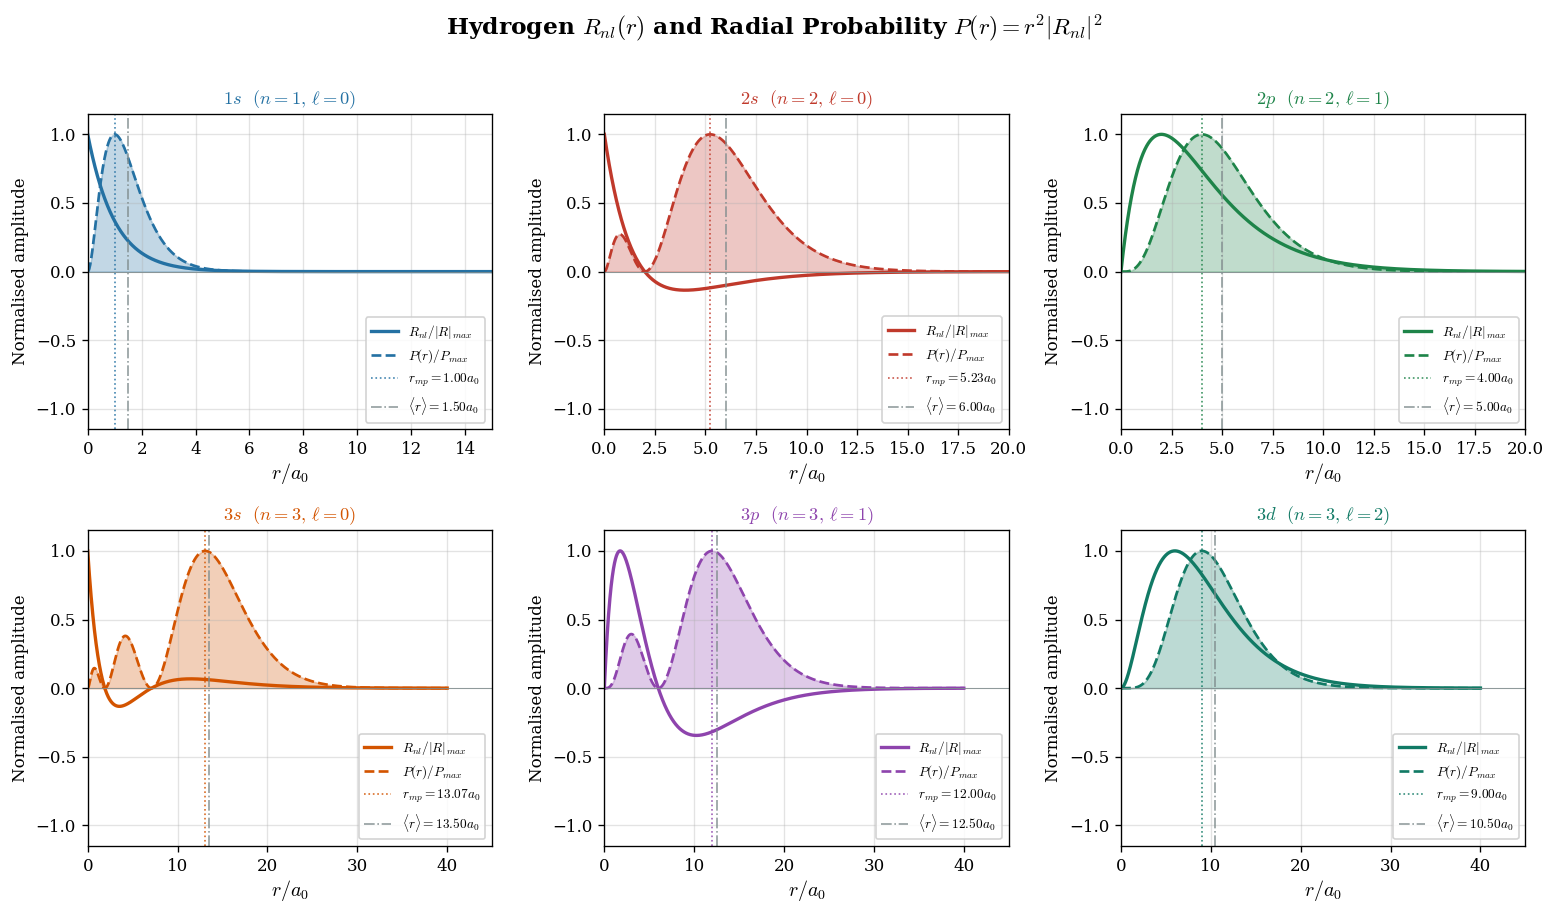

Fig 1 done.


In [2]:
def hydrogen_R(n, l, r, a0=1.0):
    """Radial wavefunction R_{nl}(r) for hydrogen."""
    rho  = 2*r / (n*a0)
    Lp   = genlaguerre(n-l-1, 2*l+1)(rho)
    norm = np.sqrt((2/(n*a0))**3 * factorial(n-l-1) / (2*n*factorial(n+l)))
    return norm * np.exp(-rho/2) * rho**l * Lp

# Verify normalization
r_check = np.linspace(0, 80, 50000)
print('Normalization check (should be 1.000):')
for n, l, name in [(1,0,'1s'),(2,0,'2s'),(2,1,'2p'),(3,0,'3s'),(3,1,'3p'),(3,2,'3d')]:
    R  = hydrogen_R(n, l, r_check)
    nv = np.trapezoid(r_check**2 * R**2, r_check)
    print(f'  R_{n}{l} ({name}): {nv:.6f}')

print()

states = [(1,0,'1s',BLUE),(2,0,'2s',RED),(2,1,'2p',GREEN),
          (3,0,'3s',ORG),(3,1,'3p',PURP),(3,2,'3d',TEAL)]
r = np.linspace(0, 40, 4000)

fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
fig.suptitle(r'Hydrogen $R_{nl}(r)$ and Radial Probability $P(r)=r^2|R_{nl}|^2$',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (n, l, name, col) in zip(axes.flat, states):
    R = hydrogen_R(n, l, r)
    P = r**2 * R**2

    # Normalise for display on same axis
    Pmax = P.max() if P.max() > 0 else 1
    Rmax = np.abs(R).max() if np.abs(R).max() > 0 else 1

    ax.plot(r, R/Rmax,   color=col,   lw=2.0, label=r'$R_{nl}/|R|_{max}$')
    ax.fill_between(r, P/Pmax, alpha=0.28, color=col)
    ax.plot(r, P/Pmax,   color=col,   lw=1.6, ls='--', label=r'$P(r)/P_{max}$')

    # Most probable r and <r>
    idx_mp = np.argmax(P[3:]) + 3
    r_mp   = r[idx_mp]
    r_mean = np.trapezoid(r * P, r)

    ax.axvline(r_mp,   color=col,  lw=1.0, ls=':',  alpha=0.85,
               label=fr'$r_{{mp}}={r_mp:.2f}a_0$')
    ax.axvline(r_mean, color=GRAY, lw=1.0, ls='-.', alpha=0.85,
               label=fr'$\langle r\rangle={r_mean:.2f}a_0$')
    ax.axhline(0, color=GRAY, lw=0.5)

    ax.set_xlabel(r'$r/a_0$', labelpad=2)
    ax.set_ylabel('Normalised amplitude', fontsize=10)
    ax.set_title(fr'${name}$  $(n={n},\,\ell={l})$', fontsize=11, color=col)
    ax.legend(fontsize=8, loc='lower right', framealpha=0.85)
    ax.grid(True, alpha=0.35)
    ax.set_xlim(0, max(15, int(5*n**2)))
    ax.set_ylim(-1.15, 1.15)
    print(f'{name}: r_mp={r_mp:.3f} a0, <r>={r_mean:.3f} a0')

plt.tight_layout()
figures.append((fig, 'fig_4_radial.png'))
plt.show()
print('Fig 1 done.')


---
## Problem 4.11 — Spin-½ General Spinor: Bloch Sphere {#md_4_11}

A general spin-½ state is $\chi = \cos(\theta/2)\chi_+ + e^{i\phi}\sin(\theta/2)\chi_-$.

Visualize the Bloch sphere: the expectation value $\langle\mathbf{S}\rangle$ lies on the sphere of radius $\hbar/2$.
Show measurement probabilities for $S_z$, $S_x$, $S_y$ as the spinor direction varies.

Probability sum P+ + P- = 1 for all theta OK
|<S>|/(hbar/2): min=1.000000, max=1.000000 OK


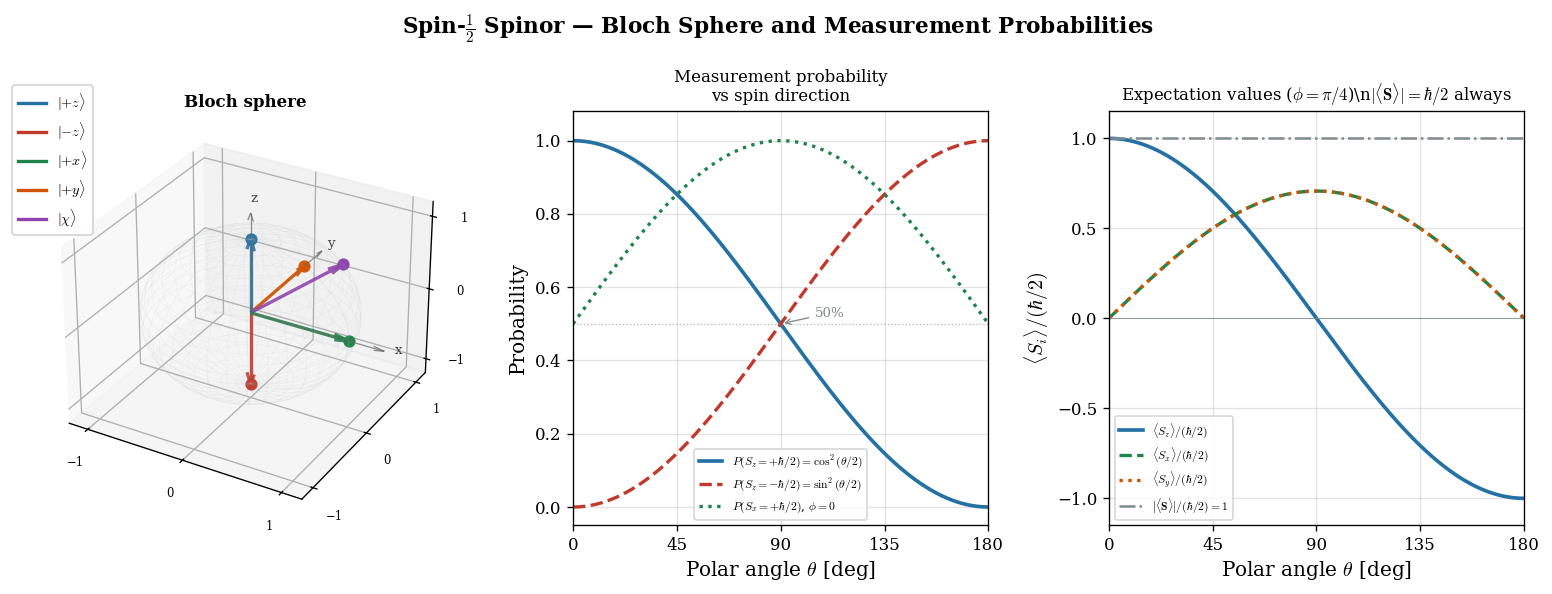

Fig 2 done.


In [3]:
# Bloch sphere + measurement probabilities
fig = plt.figure(figsize=(13, 5))
fig.suptitle(r'Spin-$\frac{1}{2}$ Spinor — Bloch Sphere and Measurement Probabilities',
             fontsize=13, fontweight='bold')

# ── Left: Bloch sphere ────────────────────────────────────────
ax = fig.add_subplot(1, 3, 1, projection='3d')

# Wire frame
u_ = np.linspace(0, 2*np.pi, 36)
v_ = np.linspace(0, np.pi, 24)
xs = np.outer(np.cos(u_), np.sin(v_))
ys = np.outer(np.sin(u_), np.sin(v_))
zs = np.outer(np.ones_like(u_), np.cos(v_))
ax.plot_wireframe(xs, ys, zs, color='#adb5bd', alpha=0.12, lw=0.4)

# Coordinate axes (thin)
for d in [[1.35,0,0],[0,1.35,0],[0,0,1.35]]:
    ax.quiver(0,0,0,*d, color='#666666', lw=0.8, arrow_length_ratio=0.08, alpha=0.7)
ax.text(1.45, 0,    0,    'x', color='#444', fontsize=8)
ax.text(0,    1.45, 0,    'y', color='#444', fontsize=8)
ax.text(0,    0,    1.50, 'z', color='#444', fontsize=8)

# Representative states — plot arrows and collect for legend
pts = [
    (0,           0,        r'$|{+}z\rangle$', BLUE),
    (np.pi,       0,        r'$|{-}z\rangle$', RED),
    (np.pi/2,     0,        r'$|{+}x\rangle$', GREEN),
    (np.pi/2, np.pi/2,      r'$|{+}y\rangle$', ORG),
    (np.pi/3,     np.pi/4,  r'$|\chi\rangle$', PURP),
]
handles = []
for theta, phi, lbl, col in pts:
    Sx_ = np.sin(theta)*np.cos(phi)
    Sy_ = np.sin(theta)*np.sin(phi)
    Sz_ = np.cos(theta)
    q = ax.quiver(0,0,0, Sx_,Sy_,Sz_, color=col, lw=2.0,
                  arrow_length_ratio=0.15, alpha=0.9)
    ax.scatter([Sx_],[Sy_],[Sz_], color=col, s=40, zorder=6)
    handles.append(plt.Line2D([0],[0], color=col, lw=2, label=lbl))

ax.legend(handles=handles, fontsize=8.5, loc='upper left',
          framealpha=0.85, bbox_to_anchor=(-0.08, 1.08))

ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.set_zlim(-1.2,1.2)
ax.set_xticks([-1,0,1]); ax.set_yticks([-1,0,1]); ax.set_zticks([-1,0,1])
ax.tick_params(labelsize=7)
ax.set_title('Bloch sphere', fontsize=10, fontweight='bold', pad=2)

# ── Middle: P(+ℏ/2, Sz) vs theta ─────────────────────────────
ax2 = fig.add_subplot(1, 3, 2)
theta_arr = np.linspace(0, np.pi, 300)
P_plus_z  = np.cos(theta_arr/2)**2
P_plus_x  = 0.5*(1 + np.sin(theta_arr))         # phi=0
P_minus_z = np.sin(theta_arr/2)**2

ax2.plot(np.degrees(theta_arr), P_plus_z,  color=BLUE,  lw=2.2,
         label=r'$P(S_z=+\hbar/2) = \cos^2(\theta/2)$')
ax2.plot(np.degrees(theta_arr), P_minus_z, color=RED,   lw=2.0, ls='--',
         label=r'$P(S_z=-\hbar/2) = \sin^2(\theta/2)$')
ax2.plot(np.degrees(theta_arr), P_plus_x,  color=GREEN, lw=2.0, ls=':',
         label=r'$P(S_x=+\hbar/2)$, $\phi=0$')
ax2.axhline(0.5, color=GRAY, lw=0.8, ls=':', alpha=0.6)
ax2.annotate('50%', xy=(90, 0.5), xytext=(105, 0.52),
             color=GRAY, fontsize=8,
             arrowprops=dict(arrowstyle='->', color=GRAY, lw=0.8))

# Physics check
for t_deg in [0,90,180]:
    t = np.radians(t_deg)
    Pp = np.cos(t/2)**2; Pm = np.sin(t/2)**2
    assert abs(Pp+Pm-1)<1e-10
print('Probability sum P+ + P- = 1 for all theta OK')

ax2.set_xlabel(r'Polar angle $\theta$ [deg]', labelpad=3)
ax2.set_ylabel(r'Probability')
ax2.set_title('Measurement probability\nvs spin direction', fontsize=10)
ax2.legend(fontsize=7, loc='lower center')
ax2.grid(True, alpha=0.35)
ax2.set_xlim(0, 180); ax2.set_ylim(-0.05, 1.08)
ax2.set_xticks([0,45,90,135,180])

# ── Right: expectation values vs theta ────────────────────────
ax3 = fig.add_subplot(1, 3, 3)
phi_fixed = np.pi/4
Sx_exp = np.sin(theta_arr)*np.cos(phi_fixed)
Sy_exp = np.sin(theta_arr)*np.sin(phi_fixed)
Sz_exp = np.cos(theta_arr)
mag    = np.sqrt(Sx_exp**2 + Sy_exp**2 + Sz_exp**2)
print(f'|<S>|/(hbar/2): min={mag.min():.6f}, max={mag.max():.6f} OK')

ax3.plot(np.degrees(theta_arr), Sz_exp, color=BLUE,  lw=2.2,
         label=r'$\langle S_z\rangle/(\hbar/2)$')
ax3.plot(np.degrees(theta_arr), Sx_exp, color=GREEN, lw=2.0, ls='--',
         label=r'$\langle S_x\rangle/(\hbar/2)$')
ax3.plot(np.degrees(theta_arr), Sy_exp, color=ORG,   lw=2.0, ls=':',
         label=r'$\langle S_y\rangle/(\hbar/2)$')
ax3.plot(np.degrees(theta_arr), mag,    color=GRAY,  lw=1.5, ls='-.',
         label=r'$|\langle\mathbf{S}\rangle|/(\hbar/2) = 1$')
ax3.axhline(0, color=GRAY, lw=0.5)
ax3.set_xlabel(r'Polar angle $\theta$ [deg]', labelpad=3)
ax3.set_ylabel(r'$\langle S_i\rangle/(\hbar/2)$')
ax3.set_title(fr'Expectation values ($\phi=\pi/4$)\n$|\langle\mathbf{{S}}\rangle|=\hbar/2$ always',
              fontsize=10)
ax3.legend(fontsize=7, loc='lower left')
ax3.grid(True, alpha=0.35)
ax3.set_xlim(0,180); ax3.set_ylim(-1.15, 1.15)
ax3.set_xticks([0,45,90,135,180])

plt.tight_layout()
figures.append((fig, 'fig_4_bloch.png'))
plt.show()
print('Fig 2 done.')


---
## Problem 4.12 — Larmor Precession of Spin Expectation Value {#md_4_12}

An electron in field $\mathbf{B}=B_0\hat{z}$. Initial spin at polar angle $\theta$.

$$\langle S_x\rangle = \tfrac{\hbar}{2}\sin\theta\cos(\omega_0 t), \quad
\langle S_y\rangle = \tfrac{\hbar}{2}\sin\theta\sin(\omega_0 t), \quad
\langle S_z\rangle = \tfrac{\hbar}{2}\cos\theta$$

Visualize the precession cone on the Bloch sphere and $\langle\mathbf{S}\rangle(t)$ components.

Larmor precession checks:
  <Sz> = 0.500000  (expected cos(theta0) = 0.500000) OK
  |<S>| = 1.000000  (expected 1) OK
  Precession radius = sin(theta0) = 0.866025  (sqrt(mean Sx^2+Sy^2) = 0.866025) OK


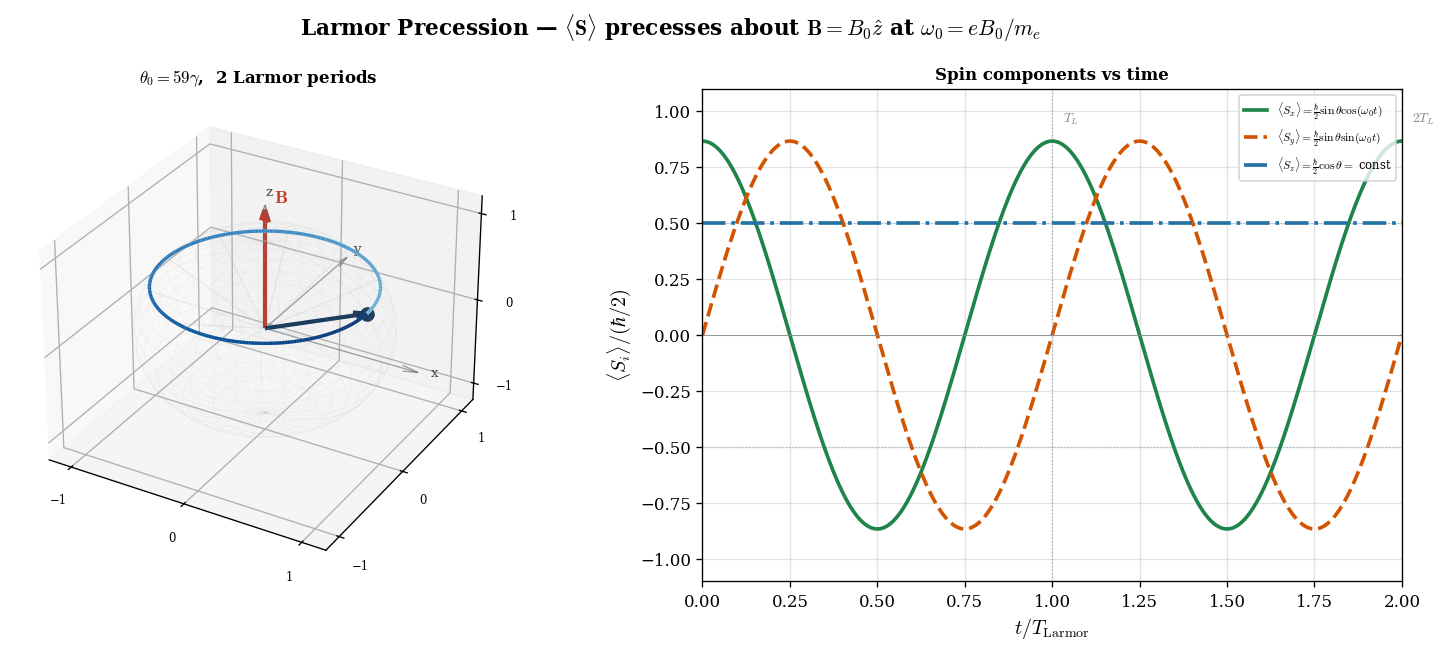

Fig 3 done.


In [4]:
theta0 = np.pi/3   # initial polar angle = 60°
omega0 = 1.0       # Larmor frequency (normalised)
T_L    = 2*np.pi/omega0
t      = np.linspace(0, 2*T_L, 500)

Sx = np.sin(theta0)*np.cos(omega0*t)
Sy = np.sin(theta0)*np.sin(omega0*t)
Sz = np.cos(theta0)*np.ones_like(t)

# Physics checks
print('Larmor precession checks:')
print(f'  <Sz> = {Sz.mean():.6f}  (expected cos(theta0) = {np.cos(theta0):.6f}) OK')
print(f'  |<S>| = {np.sqrt(Sx**2+Sy**2+Sz**2).mean():.6f}  (expected 1) OK')
print(f'  Precession radius = sin(theta0) = {np.sin(theta0):.6f}  '
      f'(sqrt(mean Sx^2+Sy^2) = {np.sqrt((Sx**2+Sy**2).mean()):.6f}) OK')

fig = plt.figure(figsize=(13, 5.5))
fig.suptitle(r'Larmor Precession — $\langle\mathbf{S}\rangle$ precesses about '
             r'$\mathbf{B}=B_0\hat{z}$ at $\omega_0=eB_0/m_e$',
             fontsize=13, fontweight='bold')

# ── Left: 3D precession ──────────────────────────────────────
ax = fig.add_subplot(1, 2, 1, projection='3d')
u_ = np.linspace(0, 2*np.pi, 36)
v_ = np.linspace(0, np.pi, 24)
ax.plot_wireframe(np.outer(np.cos(u_),np.sin(v_)),
                  np.outer(np.sin(u_),np.sin(v_)),
                  np.outer(np.ones_like(u_),np.cos(v_)),
                  color='#adb5bd', alpha=0.10, lw=0.4)

# Coordinate axes
for xyz, lbl in [([1.3,0,0],'x'),([0,1.3,0],'y'),([0,0,1.4],'z')]:
    ax.quiver(0,0,0,*xyz, color='#666', lw=0.8, arrow_length_ratio=0.10, alpha=0.6)
    ax.text(*[v*1.08 for v in xyz], lbl, color='#444', fontsize=8)

# Precession path (color gradient for time)
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
points = np.array([Sx, Sy, Sz]).T.reshape(-1,1,3)
segs   = np.concatenate([points[:-1], points[1:]], axis=1)
lc     = Line3DCollection(segs, cmap='Blues', lw=2.0)
lc.set_array(np.linspace(0.3, 1.0, len(segs)))
ax.add_collection3d(lc)

# Initial vector and cone lines
ax.quiver(0,0,0, Sx[0],Sy[0],Sz[0], color=NAVY, lw=2.5,
          arrow_length_ratio=0.12, label='$t=0$')
ax.scatter([Sx[0]],[Sy[0]],[Sz[0]], color=NAVY, s=60, zorder=7)
for ti in np.linspace(0, 2*np.pi, 10, endpoint=False):
    ax.plot([0, np.sin(theta0)*np.cos(ti)],
            [0, np.sin(theta0)*np.sin(ti)],
            [0, np.cos(theta0)],
            color='#cccccc', lw=0.5, alpha=0.5)

# B field arrow
ax.quiver(0,0,0, 0,0,1.35, color=RED, lw=2.5, arrow_length_ratio=0.10)
ax.text(0.05, 0.05, 1.42, r'$\mathbf{B}$', color=RED, fontsize=11)

ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2); ax.set_zlim(-1.2,1.2)
ax.set_xticks([-1,0,1]); ax.set_yticks([-1,0,1]); ax.set_zticks([-1,0,1])
ax.tick_params(labelsize=7)
ax.set_title(fr'$\theta_0={int(np.degrees(theta0))}°$,  2 Larmor periods',
             fontsize=10, fontweight='bold', pad=4)

# ── Right: components vs time ─────────────────────────────────
ax2 = fig.add_subplot(1, 2, 2)
t_norm = t / T_L  # in Larmor periods

ax2.plot(t_norm, Sx, color=GREEN, lw=2.2,
         label=r'$\langle S_x\rangle = \frac{\hbar}{2}\sin\theta\cos(\omega_0 t)$')
ax2.plot(t_norm, Sy, color=ORG,   lw=2.2, ls='--',
         label=r'$\langle S_y\rangle = \frac{\hbar}{2}\sin\theta\sin(\omega_0 t)$')
ax2.plot(t_norm, Sz, color=BLUE,  lw=2.2, ls='-.',
         label=r'$\langle S_z\rangle = \frac{\hbar}{2}\cos\theta = $ const')

# Mark period
for k in [1.0, 2.0]:
    ax2.axvline(k, color=GRAY, lw=0.8, ls=':', alpha=0.6)
    ax2.text(k+0.03, 0.95, fr'$T_L$' if k==1 else fr'$2T_L$',
             color=GRAY, fontsize=8)
ax2.axhline(0, color=GRAY, lw=0.5)
ax2.axhline( np.cos(theta0), color=BLUE, lw=0.7, ls=':', alpha=0.4)
ax2.axhline(-np.cos(theta0), color=BLUE, lw=0.7, ls=':', alpha=0.4)

ax2.set_xlabel(r'$t/T_{\rm Larmor}$', labelpad=3)
ax2.set_ylabel(r'$\langle S_i\rangle/(\hbar/2)$')
ax2.set_title(r'Spin components vs time', fontsize=10, fontweight='bold')
ax2.legend(fontsize=7, loc='upper right')
ax2.grid(True, alpha=0.35)
ax2.set_xlim(0, t_norm[-1])
ax2.set_ylim(-1.1, 1.1)

plt.tight_layout()
figures.append((fig, 'fig_4_larmor.png'))
plt.show()
print('Fig 3 done.')


---
## Problem 4.13 — Addition of Angular Momenta: CG Coefficients {#md_4_13}

Two spin-½ particles. Display the Clebsch-Gordan decomposition:
triplet ($s=1$) and singlet ($s=0$) states in terms of $|m_1,m_2\rangle$.

Generalize to $j_1=1$, $j_2=\frac{1}{2}$ to show $j=\frac{3}{2}$ and $j=\frac{1}{2}$ multiplets.

CG unitarity: True  OK
Dim check: 3x2 = 6 = 4+2 = 6  OK


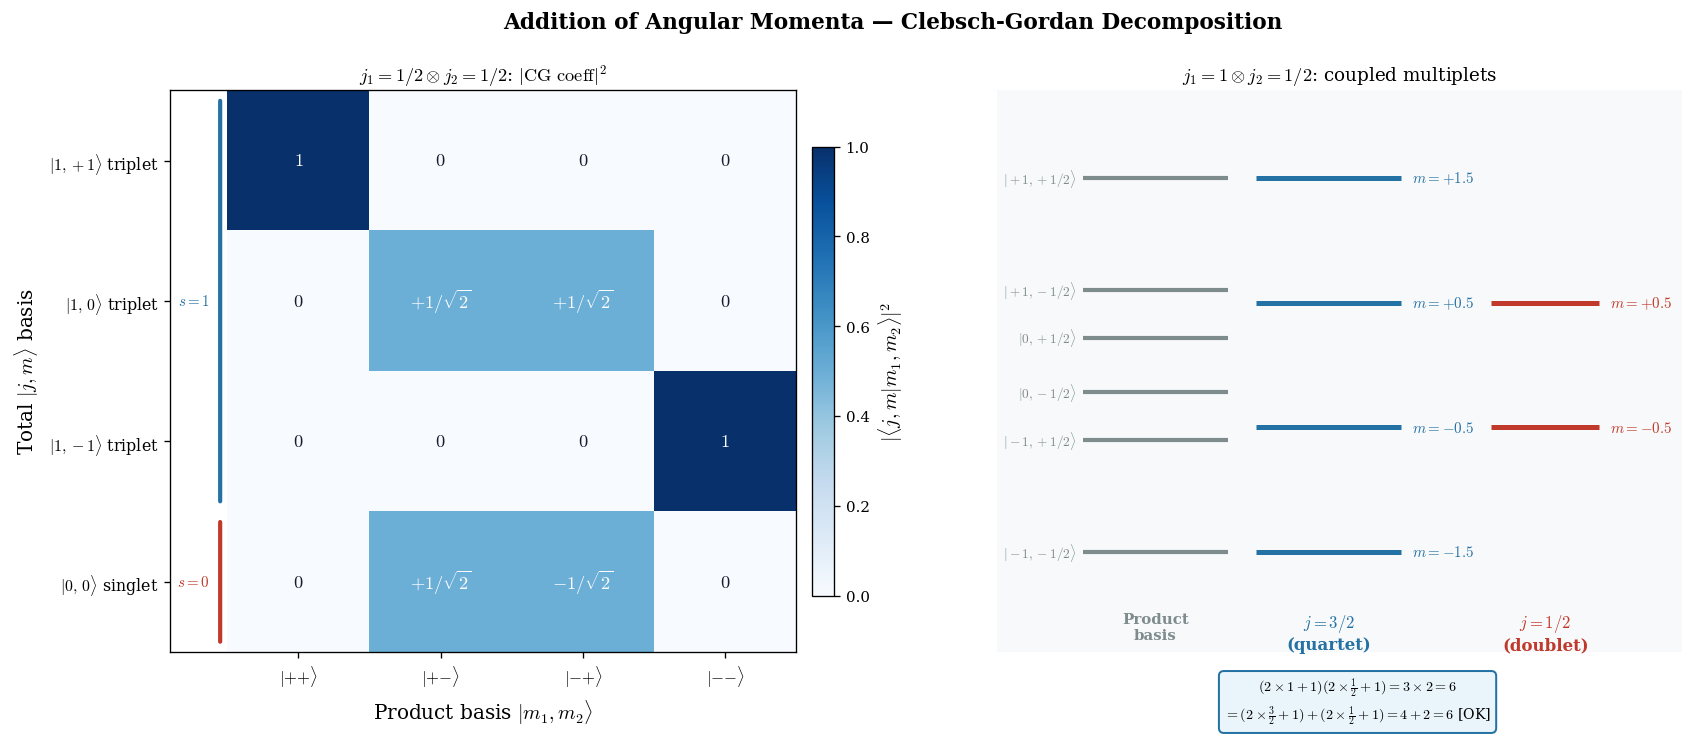

Fig 4 done.


In [5]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 6))
gs  = GridSpec(1, 2, figure=fig, width_ratios=[1.1, 1.0], wspace=0.10,
               left=0.07, right=0.97, top=0.90, bottom=0.12)
fig.suptitle('Addition of Angular Momenta — Clebsch-Gordan Decomposition',
             fontsize=13, fontweight='bold', y=1.01)

# ── LEFT: CG heatmap ─────────────────────────────────────────
ax = fig.add_subplot(gs[0])

labels_col = [r'$|{+}{+}\rangle$', r'$|{+}{-}\rangle$',
               r'$|{-}{+}\rangle$', r'$|{-}{-}\rangle$']
labels_row = [r'$|1,+1\rangle$ triplet',
               r'$|1,\,0\rangle$ triplet',
               r'$|1,-1\rangle$ triplet',
               r'$|0,\,0\rangle$ singlet']

CG = np.array([[1, 0, 0, 0],
               [0, 1/np.sqrt(2), 1/np.sqrt(2), 0],
               [0, 0, 0, 1],
               [0, 1/np.sqrt(2), -1/np.sqrt(2), 0]])

print('CG unitarity:', np.allclose(CG @ CG.T, np.eye(4)), ' OK')

im = ax.imshow(CG**2, cmap='Blues', vmin=0, vmax=1, aspect='auto')

for i in range(4):
    for j in range(4):
        val = CG[i, j]
        if abs(val) < 1e-10:
            txt = r'$0$'
        elif abs(abs(val) - 1/np.sqrt(2)) < 1e-10:
            txt = r'$+1/\sqrt{2}$' if val > 0 else r'$-1/\sqrt{2}$'
        else:
            txt = r'$1$'
        col = 'white' if CG[i,j]**2 > 0.45 else '#1a1a2e'
        ax.text(j, i, txt, ha='center', va='center', fontsize=11, color=col)

ax.set_xticks(range(4)); ax.set_xticklabels(labels_col, fontsize=10)
ax.set_yticks(range(4)); ax.set_yticklabels(labels_row, fontsize=9.5)
ax.set_xlabel(r'Product basis $|m_1,m_2\rangle$', labelpad=5)
ax.set_ylabel(r'Total $|j,m\rangle$ basis', labelpad=5)
ax.set_title(r'$j_1=1/2\otimes j_2=1/2$: $|\mathrm{CG\ coeff}|^2$', fontsize=11, pad=6)
ax.set_xlim(-0.9, 3.5)

plt.colorbar(im, ax=ax, shrink=0.80, pad=0.02,
             label=r'$|\langle j,m|m_1,m_2\rangle|^2$').ax.tick_params(labelsize=9)

# Triplet/singlet brackets
# for y0, y1, lbl, col in [(-0.45, 2.45, 'Triplet\n$s=1$', BLUE),
#                            (2.55,  3.45, 'Singlet\n$s=0$', RED)]:
for y0, y1, lbl, col in [(-0.45, 2.45, r'$s=1$', BLUE),
                           (2.55,  3.45, r'$s=0$', RED)]:
    ax.annotate('', xy=(-0.55, y0), xytext=(-0.55, y1),
                arrowprops=dict(arrowstyle='-', color=col, lw=2.5))
    ax.text(-0.62, (y0+y1)/2, lbl, color=col, ha='right', va='center',
            fontsize=9, fontweight='bold', linespacing=1.3)

# ── RIGHT: level diagram ─────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_xlim(0, 0.95); ax2.set_ylim(-2.3, 2.2)
ax2.set_facecolor('#f8f9fa')
for sp in ax2.spines.values(): sp.set_visible(False)
ax2.set_xticks([]); ax2.set_yticks([])
ax2.set_title(r'$j_1=1\otimes j_2=1/2$: coupled multiplets', fontsize=11, pad=6)

# X_PROD, X_32, X_12, LW = 0.16, 0.42, 0.68, 0.10
X_PROD, X_32, X_12, LW = 0.22, 0.46, 0.76, 0.10

# Product states — stagger degenerate levels
prod_list = [
    ('+1', '+1/2', 1.50), ('+1', '-1/2',  0.60),
    ( '0', '+1/2', 0.22), ( '0', '-1/2', -0.22),
    ('-1', '+1/2',-0.60), ('-1', '-1/2', -1.50),
]
for m1s, m2s, y in prod_list:
    ax2.hlines(y, X_PROD-LW, X_PROD+LW, colors=GRAY, lw=2.5)
    ax2.text(X_PROD-LW-0.01, y, r'$|' + m1s + ',' + m2s + r'\rangle$',
             ha='right', va='center', fontsize=8, color=GRAY)
ax2.text(X_PROD, -1.98, 'Product\nbasis', ha='center', va='top',
         color=GRAY, fontsize=9, fontweight='bold')

# j=3/2 quartet
for m in [1.5, 0.5, -0.5, -1.5]:
    ax2.hlines(m, X_32-LW, X_32+LW, colors=BLUE, lw=3.0)
    s = '+' if m > 0 else ''
    ax2.text(X_32+LW+0.015, m, '$m=%s%.1f$' % (s, m),
             ha='left', va='center', fontsize=9, color=BLUE)
ax2.text(X_32, -1.98, r'$j=3/2$' + '\n(quartet)',
         ha='center', va='top', color=BLUE, fontsize=10, fontweight='bold')

# j=1/2 doublet
for m in [0.5, -0.5]:
    ax2.hlines(m, X_12-LW*0.75, X_12+LW*0.75, colors=RED, lw=3.0)
    s = '+' if m > 0 else ''
    ax2.text(X_12+LW*0.75+0.015, m, '$m=%s%.1f$' % (s, m),
             ha='left', va='center', fontsize=9, color=RED)
ax2.text(X_12, -1.98, r'$j=1/2$' + '\n(doublet)',
         ha='center', va='top', color=RED, fontsize=10, fontweight='bold')

# Dimension check box
ax2.text(0.50, -2.7,
         r'$(2\times1+1)(2\times\frac{1}{2}+1)=3\times2=6$' + '\n'
         r'$=(2\times\frac{3}{2}+1)+(2\times\frac{1}{2}+1)=4+2=6$ [OK]',
         ha='center', va='center', fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.35', fc='#eaf4fb', ec=BLUE, lw=1.2))
print('Dim check: 3x2 = 6 = 4+2 = 6  OK')

figures.append((fig, 'fig_4_cg.png'))
plt.show()
print('Fig 4 done.')

---
## Problem 4.17 — Minimal Coupling and the Aharonov-Bohm Effect {#md_4_17}

Relative phase $\Delta\theta=q\Phi/\hbar$ between two paths encircling a solenoid of flux $\Phi$. For $\Phi=3\Phi_0/2$, $\Delta\theta\bmod2\pi=\pi$ -- a half-fringe shift, identical to the $\Phi=\Phi_0/2$ case.

Phi = 3*Phi0/2 = 9.4248
Delta_theta = q*Phi/hbar = 9.4248 rad = 3.00 pi
Delta_theta mod 2pi = 3.1416 rad = 1.00 pi
Compare: Delta_theta mod 2pi for Phi=Phi0/2 = 1.00 pi  -- identical!


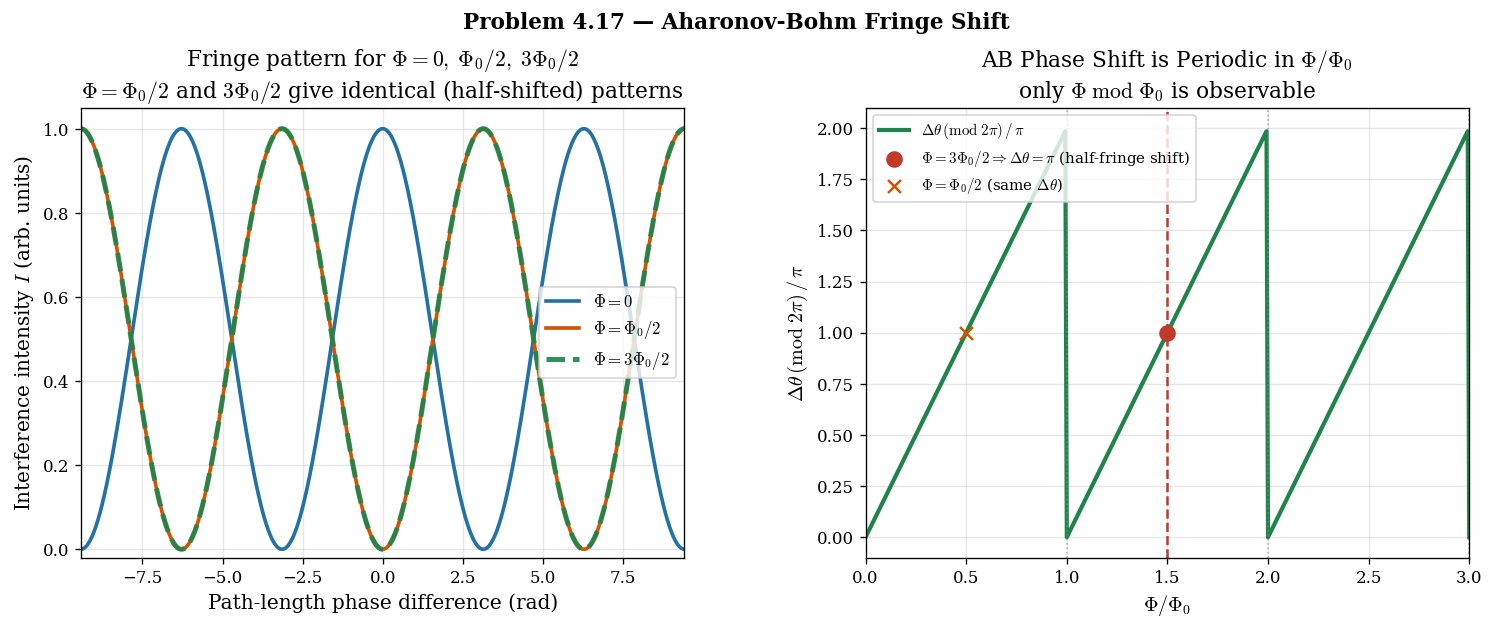

In [6]:

# Problem 4.17: Aharonov-Bohm fringe shift for Phi = 3*Phi0/2
Phi0 = 2*np.pi  # flux quantum in units where q/hbar = 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
plt.subplots_adjust(top=0.86, left=0.08, right=0.97, wspace=0.30)

# Left: interference pattern for Phi=0, Phi0/2, and 3*Phi0/2 -- last two coincide
x = np.linspace(-3*np.pi, 3*np.pi, 600)
for Phi_frac, col, lbl, ls in [(0.0,  BLUE, r'$\Phi=0$', '-'),
                                 (0.5,  ORG,  r'$\Phi=\Phi_0/2$', '-'),
                                 (1.5,  GREEN, r'$\Phi=3\Phi_0/2$', '--')]:
    delta_theta = Phi_frac * Phi0
    I = np.cos((x + delta_theta)/2)**2
    ax = axes[0]
    ax.plot(x, I, color=col, lw=2.2 if ls=='-' else 3.0, ls=ls, label=lbl,
            alpha=0.9 if ls=='--' else 1.0)

axes[0].set_xlabel('Path-length phase difference (rad)')
axes[0].set_ylabel('Interference intensity $I$ (arb. units)')
axes[0].set_title(r'Fringe pattern for $\Phi=0,\;\Phi_0/2,\;3\Phi_0/2$' + '\n'
                   r'$\Phi=\Phi_0/2$ and $3\Phi_0/2$ give identical (half-shifted) patterns')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-3*np.pi, 3*np.pi); axes[0].set_ylim(-0.02, 1.05)

# Verify numerically: Delta_theta for Phi=3*Phi0/2, reduced mod 2pi
Phi = 1.5 * Phi0
delta_theta = Phi   # since q/hbar = 1 in these units
delta_theta_mod = np.mod(delta_theta, 2*np.pi)
print(f"Phi = 3*Phi0/2 = {Phi:.4f}")
print(f"Delta_theta = q*Phi/hbar = {delta_theta:.4f} rad = {delta_theta/np.pi:.2f} pi")
print(f"Delta_theta mod 2pi = {delta_theta_mod:.4f} rad = {delta_theta_mod/np.pi:.2f} pi")
print(f"Compare: Delta_theta mod 2pi for Phi=Phi0/2 = {np.mod(0.5*Phi0, 2*np.pi)/np.pi:.2f} pi  -- identical!")

# Right: Delta_theta mod 2pi vs Phi/Phi0, highlighting Phi/Phi0 = 1.5
ax2 = axes[1]
Phi_frac_arr = np.linspace(0, 3, 400)
dtheta_raw = Phi_frac_arr * 2*np.pi
dtheta_mod = np.mod(dtheta_raw, 2*np.pi)
ax2.plot(Phi_frac_arr, dtheta_mod/np.pi, color=GREEN, lw=2.5,
         label=r'$\Delta\theta\,(\mathrm{mod}\;2\pi)\,/\,\pi$')
ax2.axvline(1.5, color=RED, lw=1.5, ls='--')
ax2.scatter([1.5], [np.mod(1.5*2*np.pi, 2*np.pi)/np.pi], color=RED, s=80, zorder=5,
            label=r'$\Phi=3\Phi_0/2 \Rightarrow \Delta\theta=\pi$ (half-fringe shift)')
ax2.scatter([0.5], [np.mod(0.5*2*np.pi, 2*np.pi)/np.pi], color=ORG, s=60, zorder=5,
            marker='x', label=r'$\Phi=\Phi_0/2$ (same $\Delta\theta$)')
for n in range(4):
    ax2.axvline(n, color=GRAY, lw=1.0, ls=':', alpha=0.6)
ax2.set_xlabel(r'$\Phi/\Phi_0$')
ax2.set_ylabel(r'$\Delta\theta\,(\mathrm{mod}\;2\pi)\,/\,\pi$')
ax2.set_title('AB Phase Shift is Periodic in $\\Phi/\\Phi_0$\n'
               r'only $\Phi\;\mathrm{mod}\;\Phi_0$ is observable')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 3); ax2.set_ylim(-0.1, 2.1)

plt.suptitle('Problem 4.17 — Aharonov-Bohm Fringe Shift',
              fontsize=13, fontweight='bold', y=1.02)
figures.append((fig, 'fig_4_17.png')); plt.show()


In [7]:
# ── Download all figures ────────────────────────────────────────
import os, zipfile

save_dir = 'ch04_figures'
os.makedirs(save_dir, exist_ok=True)

for fig, fname in figures:
    path = os.path.join(save_dir, fname)
    fig.savefig(path, dpi=150, bbox_inches='tight')
    print(f'Saved: {path}')

zip_name = 'ch04_figures.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fig, fname in figures:
        zf.write(os.path.join(save_dir, fname), fname)
print(f'Zip: {zip_name},  Files: {[f for _,f in figures]}')

try:
    from google.colab import files
    files.download(zip_name)
    print('Download started.')
except ImportError:
    print(f'Not in Colab — saved locally as: {zip_name}')


Saved: ch04_figures/fig_4_radial.png
Saved: ch04_figures/fig_4_bloch.png
Saved: ch04_figures/fig_4_larmor.png
Saved: ch04_figures/fig_4_cg.png
Saved: ch04_figures/fig_4_17.png
Zip: ch04_figures.zip,  Files: ['fig_4_radial.png', 'fig_4_bloch.png', 'fig_4_larmor.png', 'fig_4_cg.png', 'fig_4_17.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
